# Phase 5: Post-Training Analysis & Visualization

This notebook produces all analysis figures for the MoE emergence technical report.

**Figures produced:**
1. Expert-domain heatmaps (2x2 grid, one per MoE layer)
2. Collapse comparison (with vs without load balancing)
3. Collapse trajectory (no-LB expert utilization over steps 100-500)
4. Router entropy over training
5. Python token-type routing heatmap
6. Training curves (eval loss + per-domain best-eval bars)

In [10]:
# Cell 1: Setup
import time
from pathlib import Path

import matplotlib
import pandas as pd
import torch
from transformers import AutoTokenizer

from moe_emergence.analysis import (
    build_domain_eval_blocks,
    compute_collapse_trajectory,
    compute_domain_expert_fractions,
    compute_expert_utilization_at_snapshot,
    compute_token_type_routing,
    get_best_eval_metrics,
    load_metrics_jsonl,
    load_moe_model,
)
from moe_emergence.analysis import HF_CACHE
from moe_emergence.visualize import (
    plot_collapse_comparison,
    plot_collapse_trajectory,
    plot_expert_domain_heatmap_grid,
    plot_router_entropy_over_training,
    plot_token_type_routing,
    plot_training_curves,
)

%matplotlib inline

# device selection
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

# paths
CKPT = Path("../checkpoints")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
WANDB_CSV = Path("../.cache/wandb_exports")

tokenizer = AutoTokenizer.from_pretrained("gpt2", cache_dir=str(HF_CACHE))
tokenizer.pad_token = tokenizer.eos_token
print("Setup complete.")

Device: mps
Setup complete.


In [11]:
# Cell 2: Build eval data + benchmark timing
t0 = time.time()

print("Building code eval blocks...")
code_blocks = build_domain_eval_blocks("code", tokenizer)
print(f"  {len(code_blocks)} code blocks")

print("Building math eval blocks...")
math_blocks = build_domain_eval_blocks("math", tokenizer)
print(f"  {len(math_blocks)} math blocks")

print("Building prose eval blocks...")
prose_blocks = build_domain_eval_blocks("prose", tokenizer)
print(f"  {len(prose_blocks)} prose blocks")

domain_blocks = {"code": code_blocks, "math": math_blocks, "prose": prose_blocks}
all_blocks = code_blocks + math_blocks + prose_blocks

data_time = time.time() - t0
print(f"\nData construction: {data_time:.1f}s")

# benchmark: single model load + forward pass
t1 = time.time()
test_model, test_moe, _ = load_moe_model(str(CKPT / "moe-main/final-model"), DEVICE)
load_time = time.time() - t1

t2 = time.time()
with torch.no_grad():
    test_model(all_blocks[0]["input_ids"].unsqueeze(0).to(DEVICE))
fwd_time = time.time() - t2

print(f"Model load: {load_time:.1f}s, Forward pass: {fwd_time:.3f}s")
print(f"Estimated full analysis time: ~{(load_time * 7 + fwd_time * len(all_blocks) * 5 + data_time) / 60:.0f} min")

del test_model, test_moe

Building code eval blocks...


Token indices sequence length is longer than the specified maximum sequence length for this model (2333 > 1024). Running this sequence through the model will result in indexing errors


  438 code blocks
Building math eval blocks...
  291 math blocks
Building prose eval blocks...
  228 prose blocks

Data construction: 5.4s


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2447.90it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing
Model load: 3.4s, Forward pass: 0.214s
Estimated full analysis time: ~18 min


Loading MoE main final model...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2631.62it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing
  Step 9999, mode=moe
Computing domain expert fractions...
Done in 76.6s

Layer 8:
  code: 0.145 0.095 0.138 0.140 0.078 0.134 0.159 0.111
  math: 0.182 0.185 0.052 0.060 0.242 0.076 0.122 0.081
  prose: 0.096 0.152 0.144 0.117 0.121 0.121 0.105 0.144

Layer 9:
  code: 0.147 0.132 0.149 0.093 0.135 0.124 0.094 0.125
  math: 0.122 0.094 0.069 0.151 0.101 0.112 0.216 0.135
  prose: 0.132 0.150 0.118 0.134 0.107 0.109 0.120 0.131

Layer 10:
  code: 0.164 0.124 0.081 0.150 0.123 0.117 0.102 0.139
  math: 0.117 0.135 0.178 0.057 0.093 0.083 0.260 0.076
  prose: 0.103 0.101 0.151 0.135 0.144 0.147 0.075 0.143

Layer 11:
  code: 0.154 0.120 0.119 0.126 0.121 0.105 0.143 0.112
  math: 0.131 0.123 0.139 0.100 0.101 0.151 0.132 0.123
  prose: 0.086 0.093 0.109 0.178 0.150 0.093 0.097 0.194


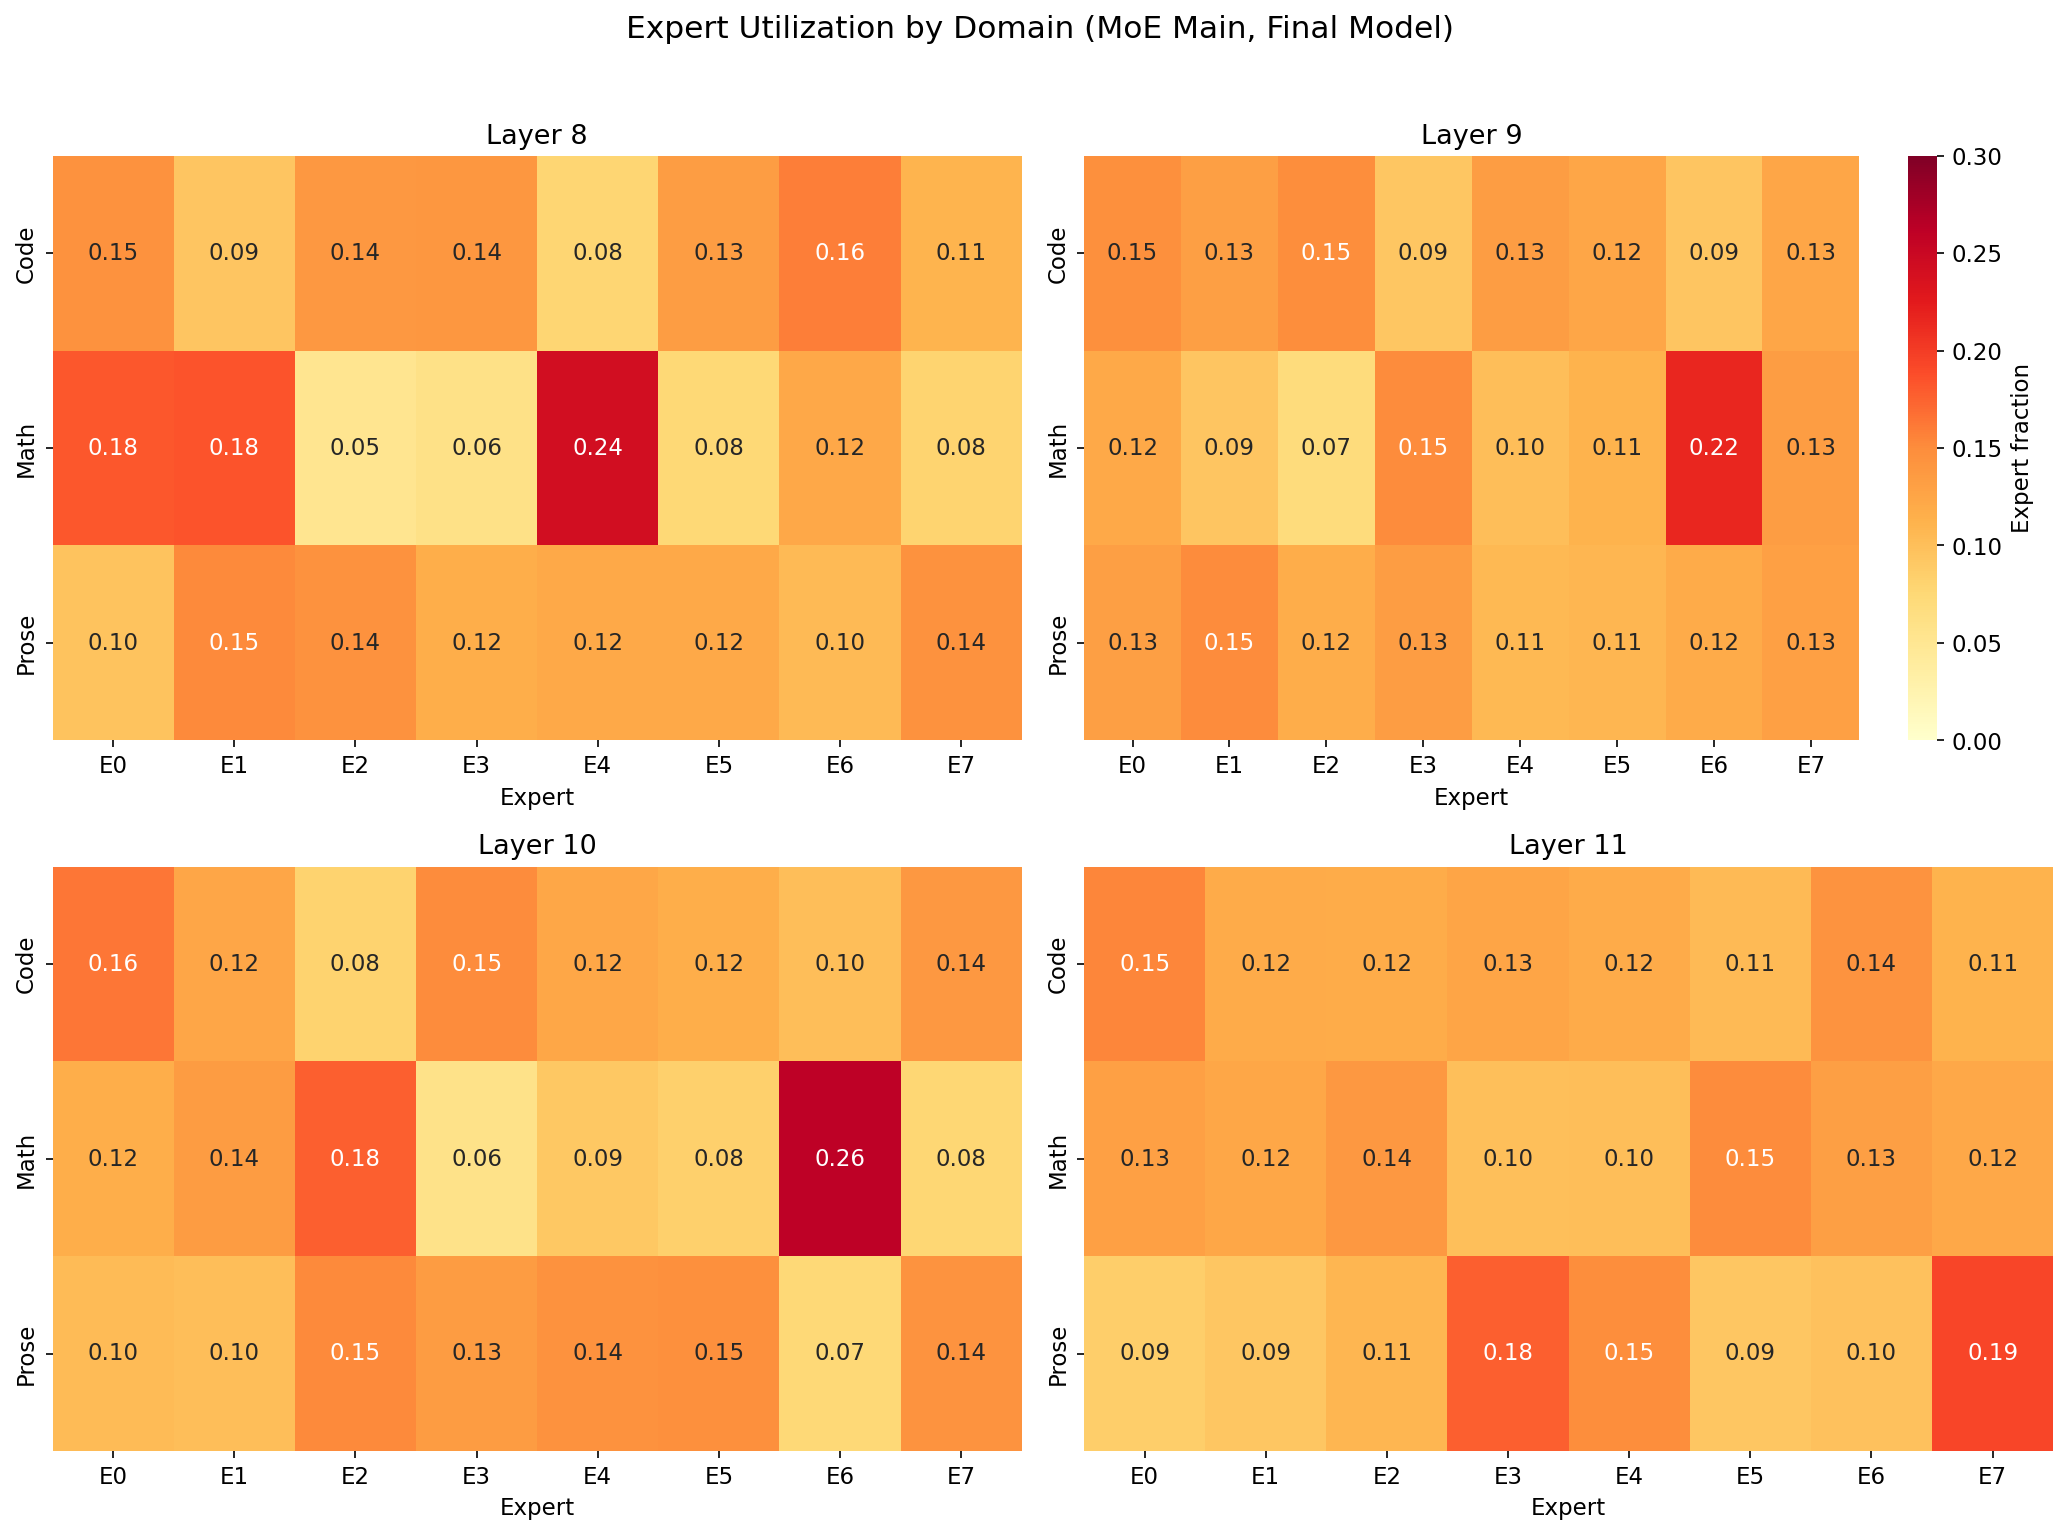

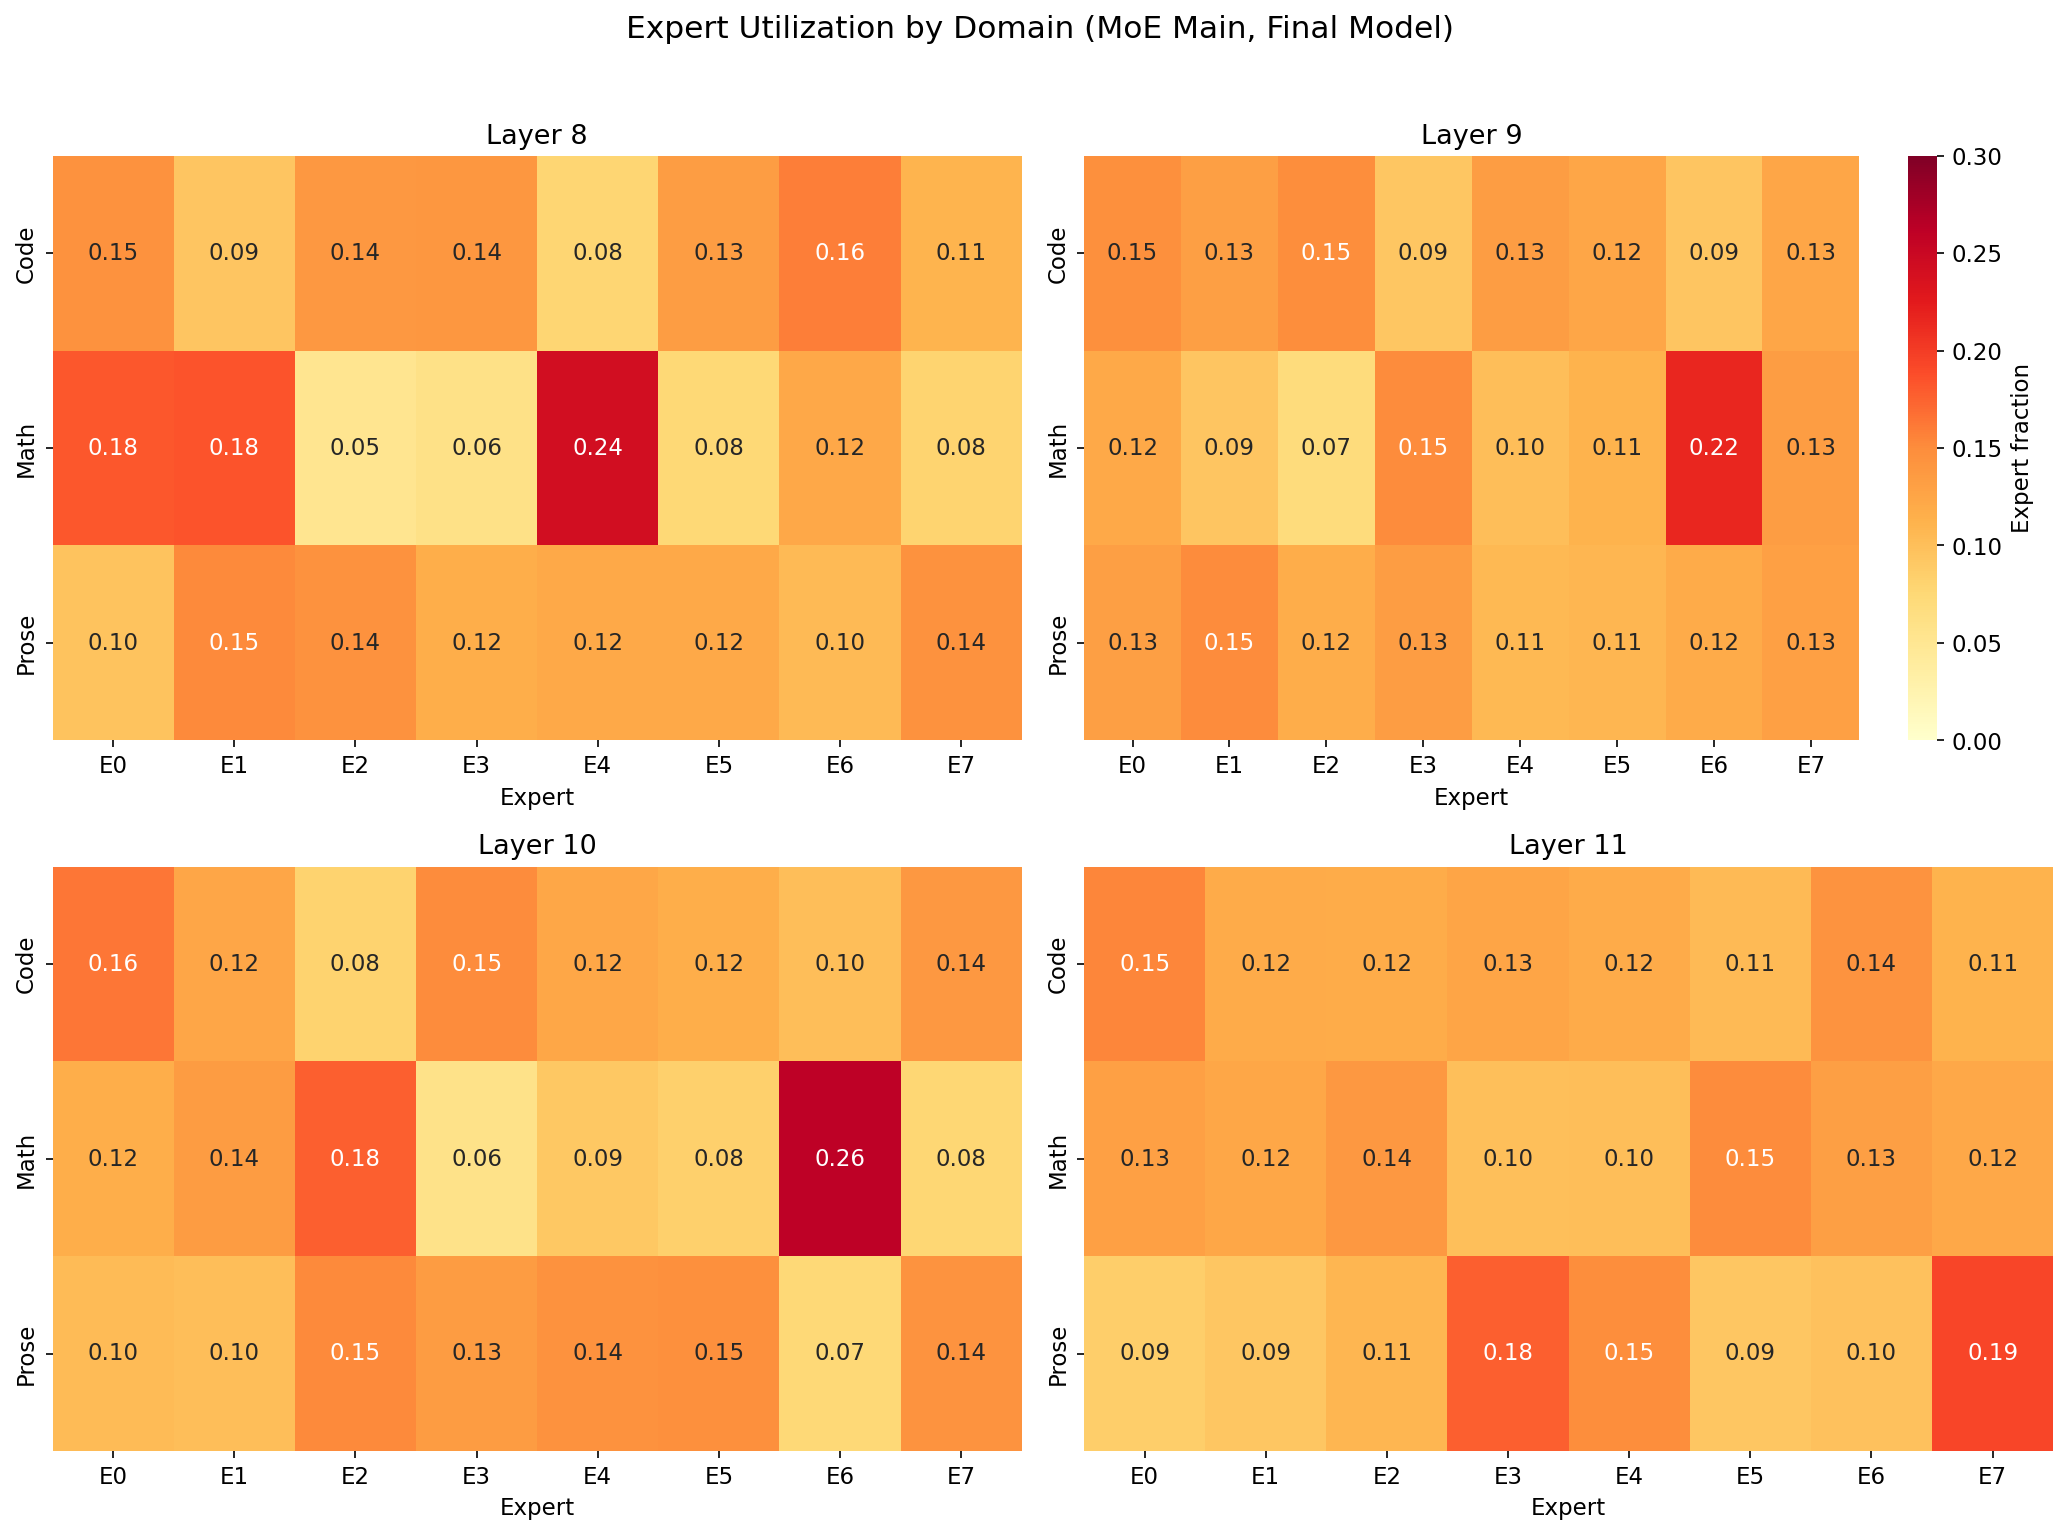

In [12]:
# Cell 3: Expert-domain heatmaps (MoE main, final model)
t0 = time.time()
print("Loading MoE main final model...")
model, moe_modules, meta = load_moe_model(str(CKPT / "moe-main/final-model"), DEVICE)
print(f"  Step {meta.get('step', '?')}, mode={meta.get('mode', '?')}")

print("Computing domain expert fractions...")
fractions = compute_domain_expert_fractions(model, moe_modules, domain_blocks, DEVICE)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

# display fractions for verification
for layer in [8, 9, 10, 11]:
    print(f"\nLayer {layer}:")
    for domain in ["code", "math", "prose"]:
        vals = fractions[layer][domain]
        print(f"  {domain}: {' '.join(f'{v:.3f}' for v in vals)}")

fig_heatmap = plot_expert_domain_heatmap_grid(fractions)
fig_heatmap

Computing MoE main aggregate utilization...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2285.34it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing

Computing no-LB collapse trajectory...
  Computing utilization at step 100...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2697.28it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing
  Computing utilization at step 200...


...

Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing
  Computing utilization at step 400...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2611.51it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing
  Computing utilization at step 500...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1452.86it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing

Done in 477.3s

No-LB layer 9 fracs at step 500: tensor([0.0339, 0.7453, 0.0445, 0.0209, 0.0176, 0.0521, 0.0758, 0.0098])
Max expert frac: 0.745


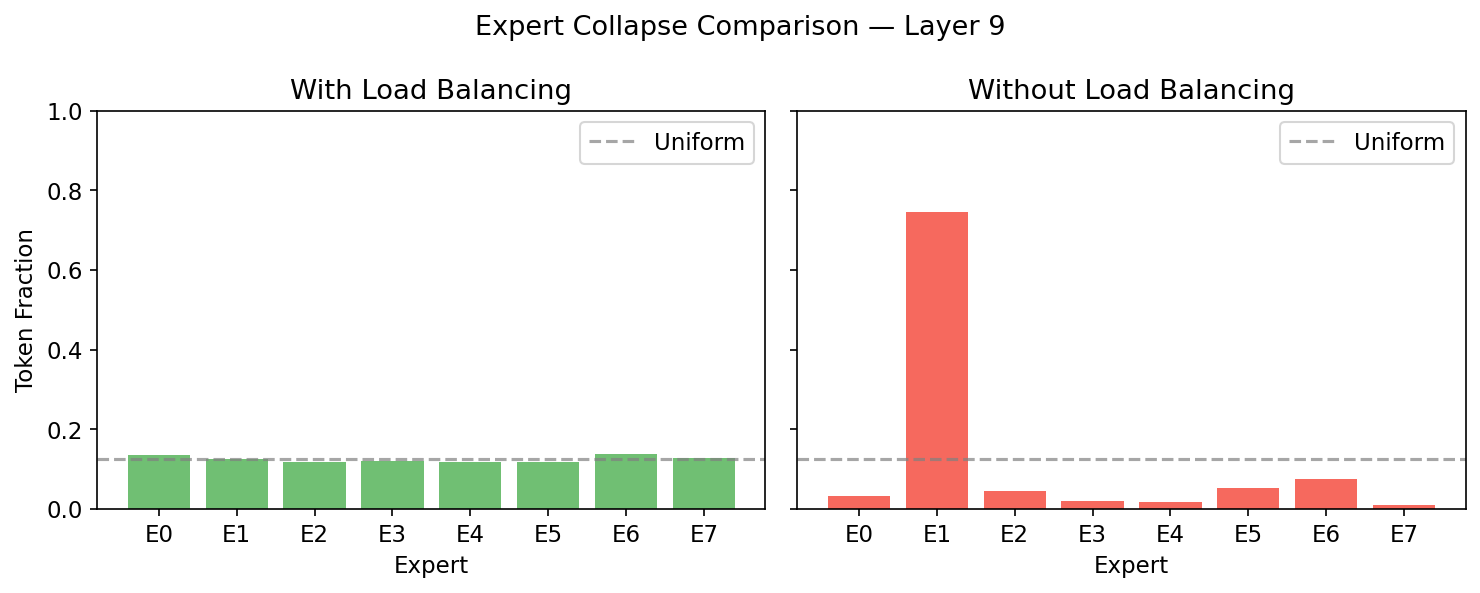

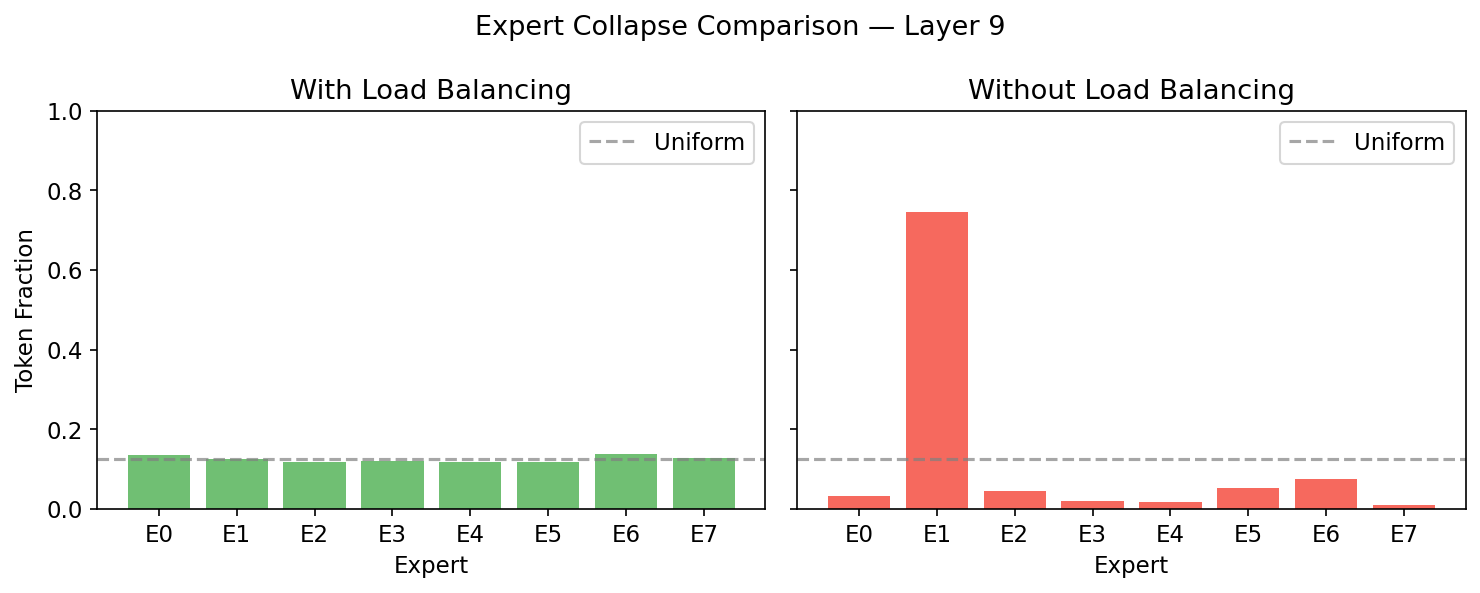

In [13]:
# Cell 4: Collapse comparison + trajectory
t0 = time.time()

# MoE main utilization (reuse from cell 3 — aggregate across all domains)
print("Computing MoE main aggregate utilization...")
moe_util = compute_expert_utilization_at_snapshot(
    str(CKPT / "moe-main/final-model"), all_blocks, DEVICE
)

# No-LB collapse trajectory
nolb_stems = [
    (100, str(CKPT / "no-lb-ablation/model-step-100")),
    (200, str(CKPT / "no-lb-ablation/model-step-200")),
    (300, str(CKPT / "no-lb-ablation/model-step-300")),
    (400, str(CKPT / "no-lb-ablation/model-step-400")),
    (500, str(CKPT / "no-lb-ablation/final-model")),
]
print("\nComputing no-LB collapse trajectory...")
trajectory = compute_collapse_trajectory(nolb_stems, all_blocks, DEVICE)

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s")

# no-lb final (step 500) utilization for comparison
nolb_util = trajectory[-1]  # step 500
nolb_fracs = {li: nolb_util[li] for li in [8, 9, 10, 11]}

# verify expected collapse: layer 9 should show dominant expert
print(f"\nNo-LB layer 9 fracs at step 500: {nolb_fracs[9]}")
print(f"Max expert frac: {nolb_fracs[9].max():.3f}")

fig_collapse = plot_collapse_comparison(moe_util, nolb_fracs, 9)
fig_collapse

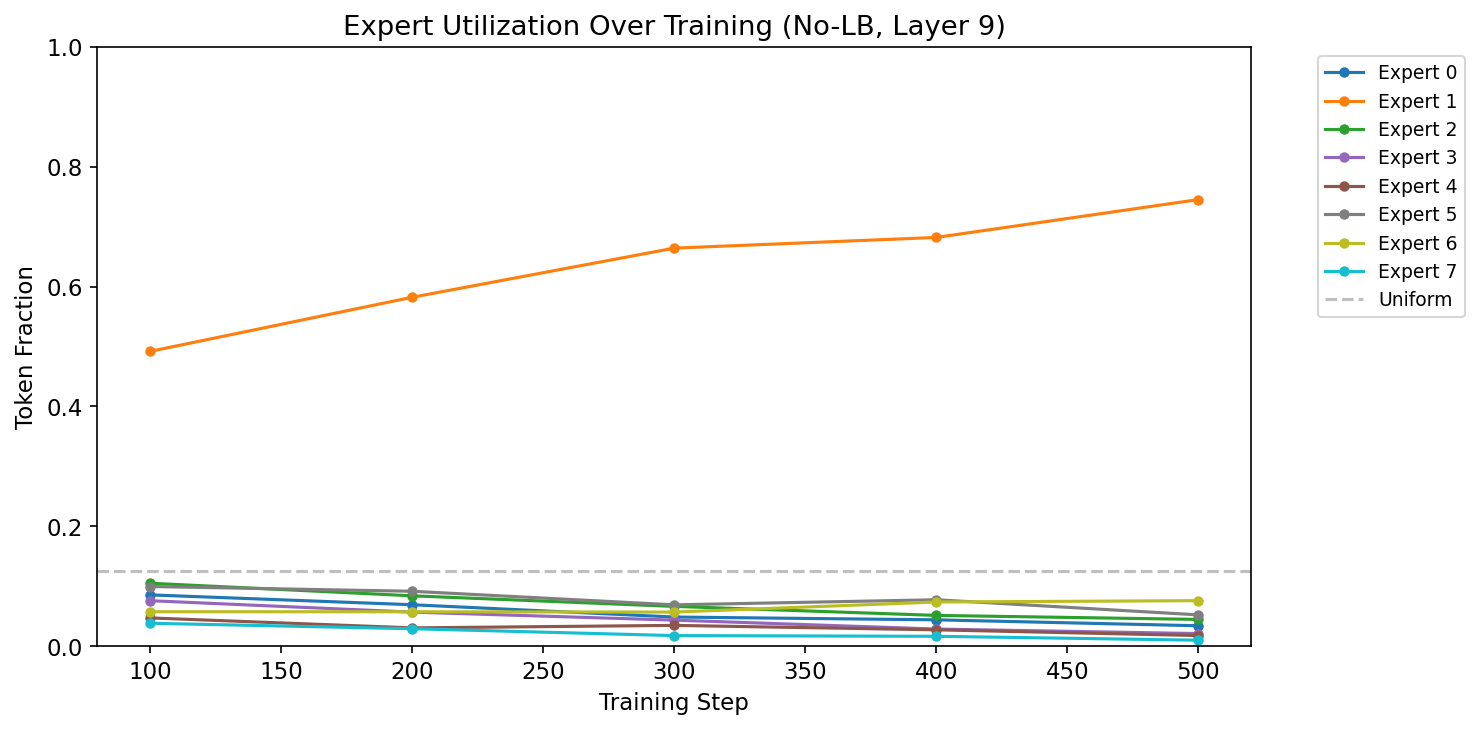

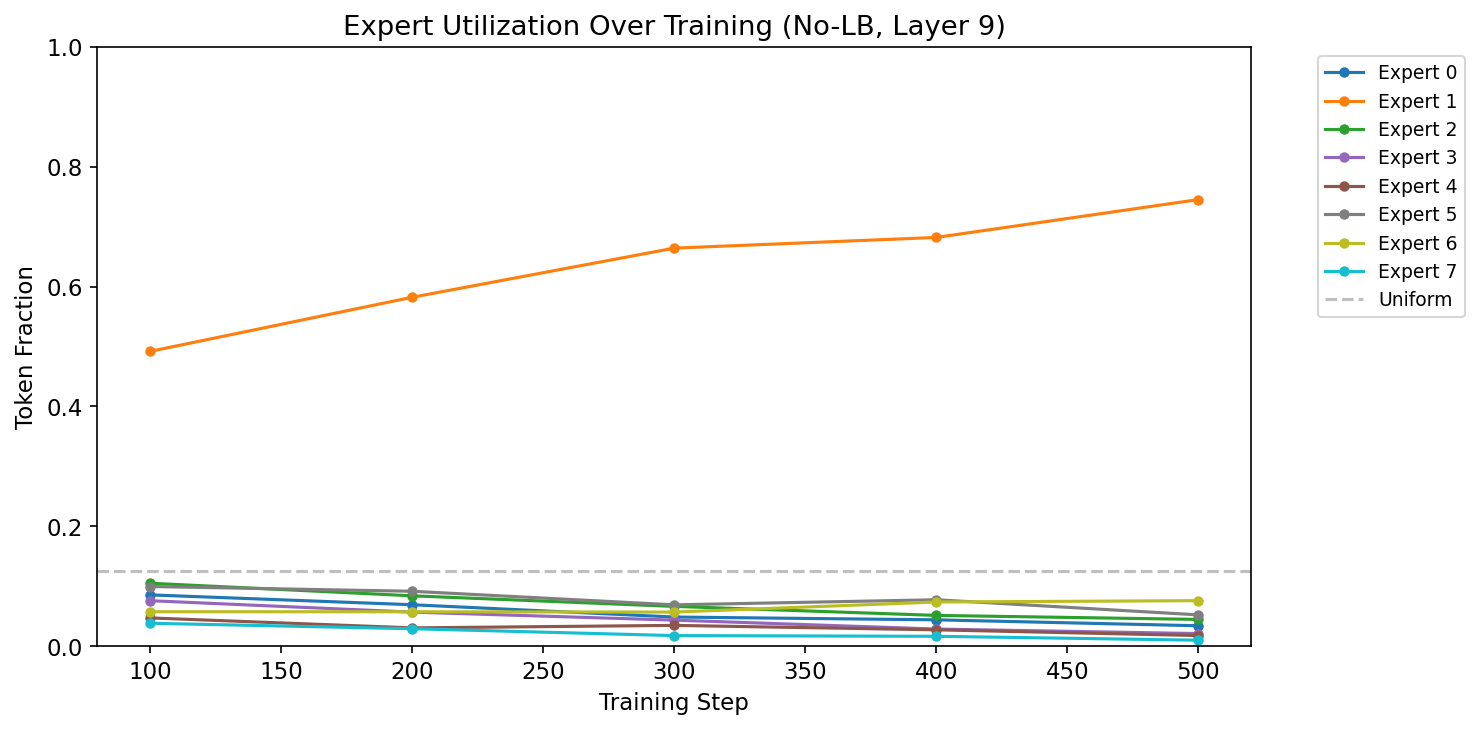

In [14]:
# Cell 4b: Collapse trajectory plot
fig_trajectory = plot_collapse_trajectory(trajectory, 9)
fig_trajectory

Loaded 100 rows of router metrics
Steps: 0 to 9900


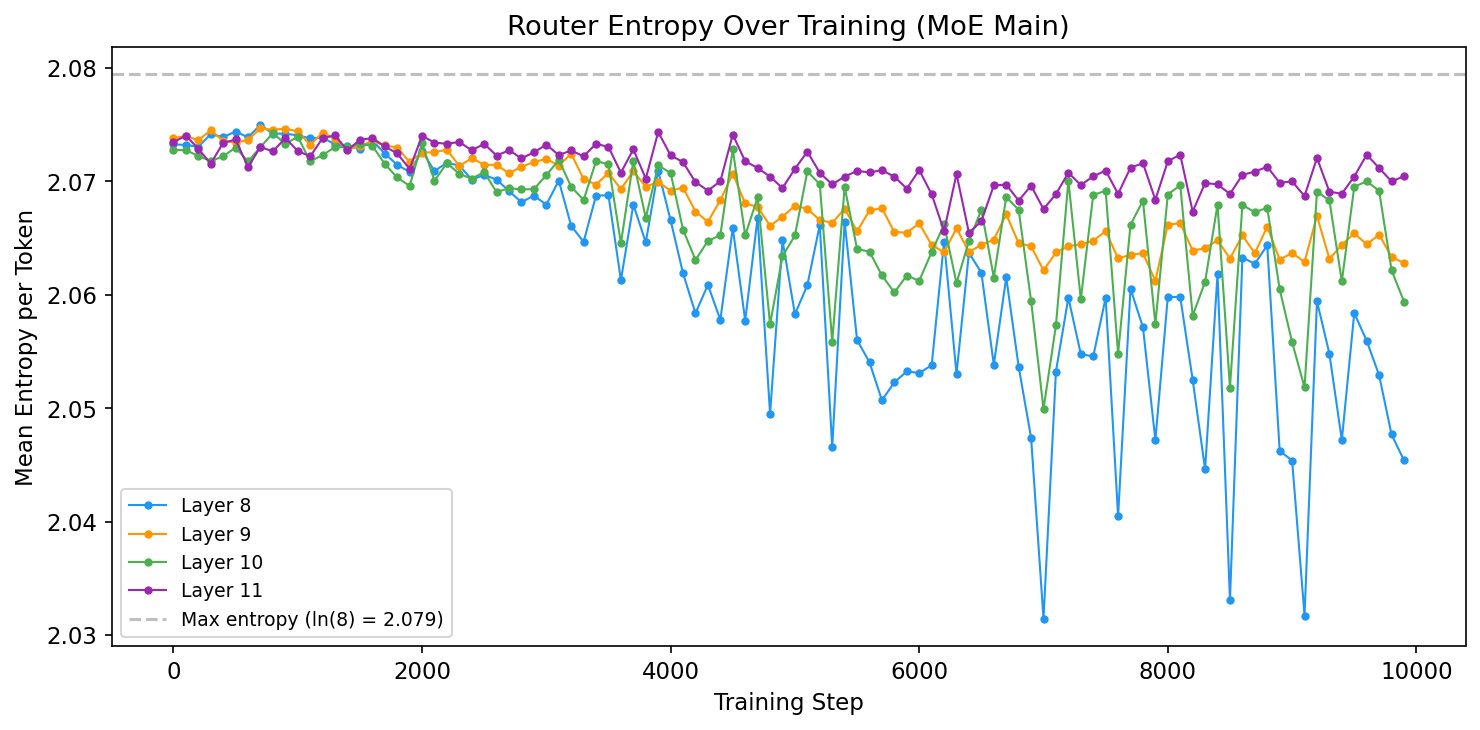

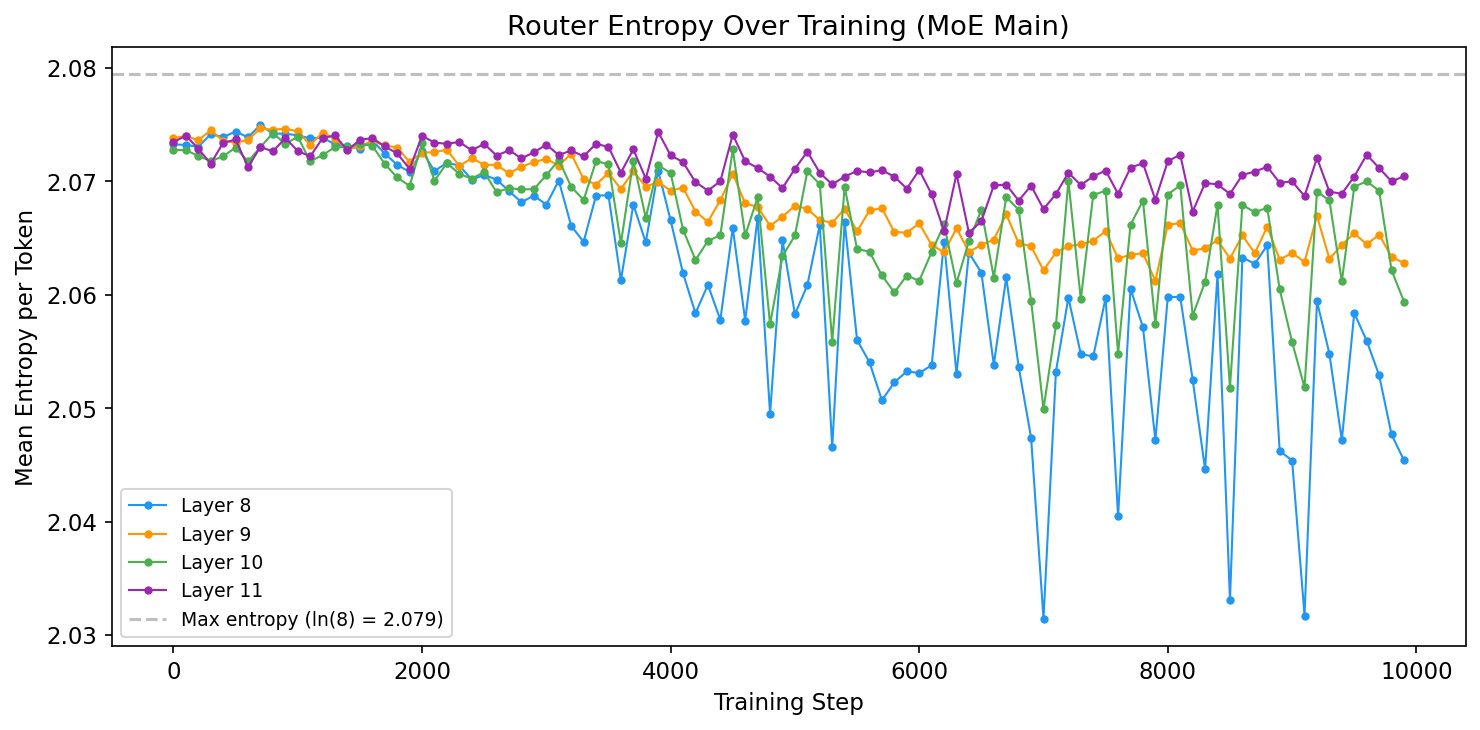

In [15]:
# Cell 5: Router entropy over training
entropy_df = pd.read_csv(WANDB_CSV / "moe-main-router-metrics.csv")
print(f"Loaded {len(entropy_df)} rows of router metrics")
print(f"Steps: {entropy_df['_step'].min()} to {entropy_df['_step'].max()}")

fig_entropy = plot_router_entropy_over_training(entropy_df)
fig_entropy

Loading MoE main model for token-type analysis...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2294.11it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Installed MoE at layer 8: 8 experts, top-1 routing
Installed MoE at layer 9: 8 experts, top-1 routing
Installed MoE at layer 10: 8 experts, top-1 routing
Installed MoE at layer 11: 8 experts, top-1 routing
Using 134 code eval texts
Computing token-type routing (this may take a few minutes)...
  Processed 50/134 files
  Processed 100/134 files
Done in 22.6s

Layer 8:
  KEYWORD   : 0.788 0.014 0.000 0.013 0.070 0.003 0.088 0.023
  NAME      : 0.080 0.051 0.095 0.295 0.073 0.129 0.260 0.019
  NUMBER    : 0.042 0.226 0.049 0.009 0.000 0.089 0.562 0.023
  STRING    : 0.102 0.082 0.132 0.226 0.089 0.105 0.160 0.103
  OP        : 0.338 0.075 0.006 0.259 0.029 0.052 0.234 0.007
  COMMENT   : 0.069 0.085 0.132 0.216 0.114 0.108 0.126 0.149

Layer 9:
  KEYWORD   : 0.125 0.195 0.091 0.036 0.042 0.107 0.112 0.291
  NAME      : 0.148 0.057 0.447 0.184 0.047 0.017 0.004 0.097
  NUMBER    : 0.471 0.068 0.191 0.007 0.089 0.075 0.005 0.096
  STRING    : 0.173 0.053 0.180 0.160 0.122 0.167 0.056 0.089
 

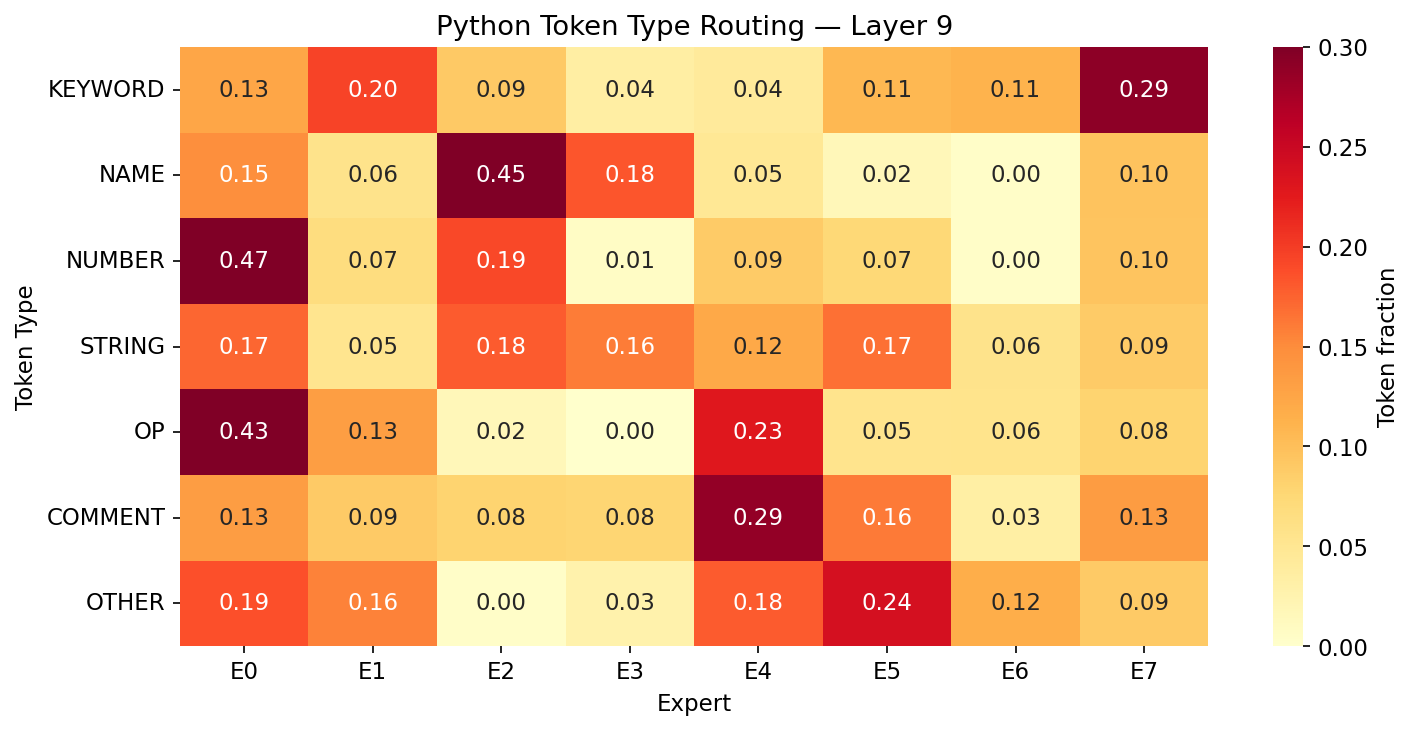

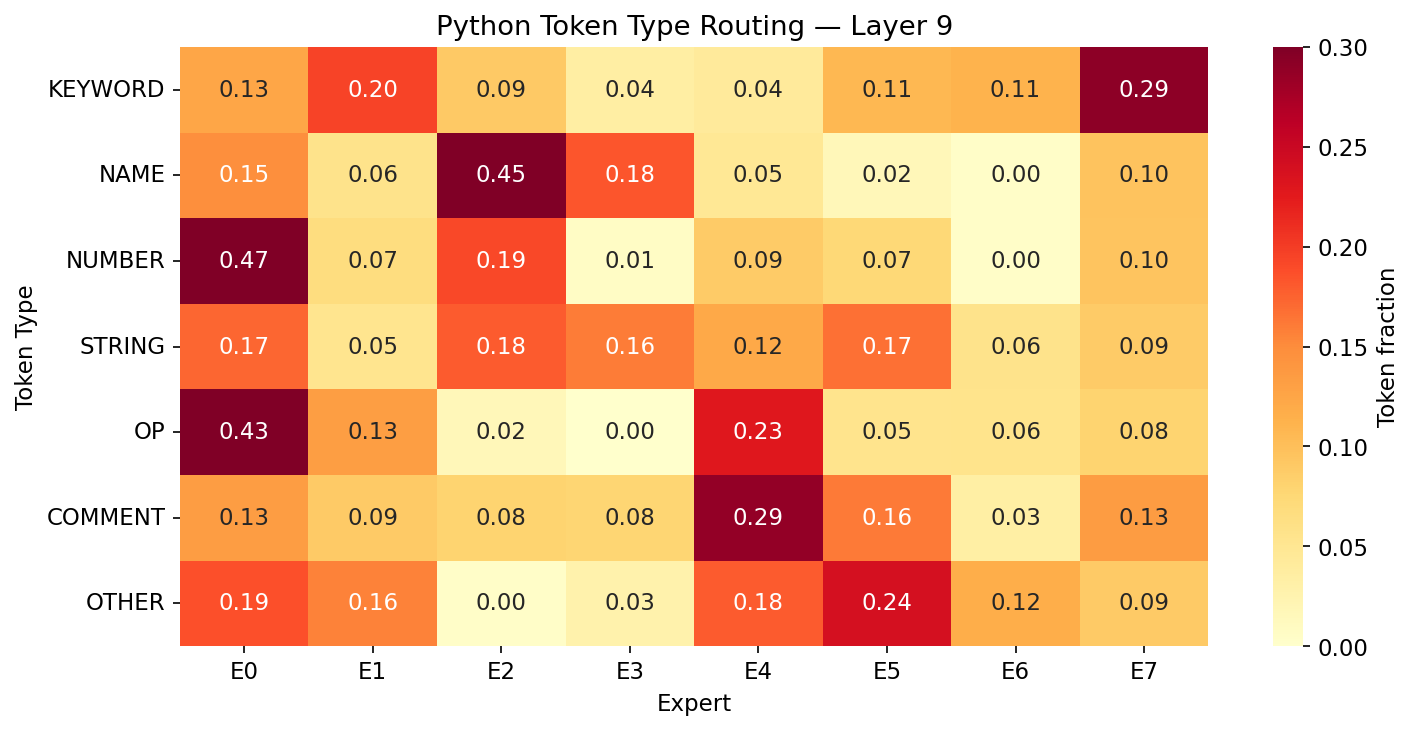

In [16]:
# Cell 6: Token-type routing analysis
t0 = time.time()
print("Loading MoE main model for token-type analysis...")
model, moe_modules, _ = load_moe_model(str(CKPT / "moe-main/final-model"), DEVICE)

# use the code eval texts (pre-packing) for token-type analysis
from moe_emergence.data import load_code_data, split_texts_for_eval

code_texts, _ = load_code_data(max_size_mb=10.0)
_, code_eval_texts = split_texts_for_eval(code_texts, seed=42)
print(f"Using {len(code_eval_texts)} code eval texts")

print("Computing token-type routing (this may take a few minutes)...")
token_type_fracs = compute_token_type_routing(
    model, moe_modules, code_eval_texts, tokenizer, DEVICE, max_samples=200
)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

# display for verification
for layer in [8, 9, 10, 11]:
    print(f"\nLayer {layer}:")
    for tt in ["KEYWORD", "NAME", "NUMBER", "STRING", "OP", "COMMENT"]:
        vals = token_type_fracs[layer].get(tt, torch.zeros(8))
        print(f"  {tt:10s}: {' '.join(f'{v:.3f}' for v in vals)}")

fig_token = plot_token_type_routing(token_type_fracs, 9)
fig_token

Best eval losses:
  dense: 2.1567 at step 4600
  moe-main: 2.0798 at step 9400
  no-lb: 2.3817 at step 400
  top-2: 2.0766 at step 8000


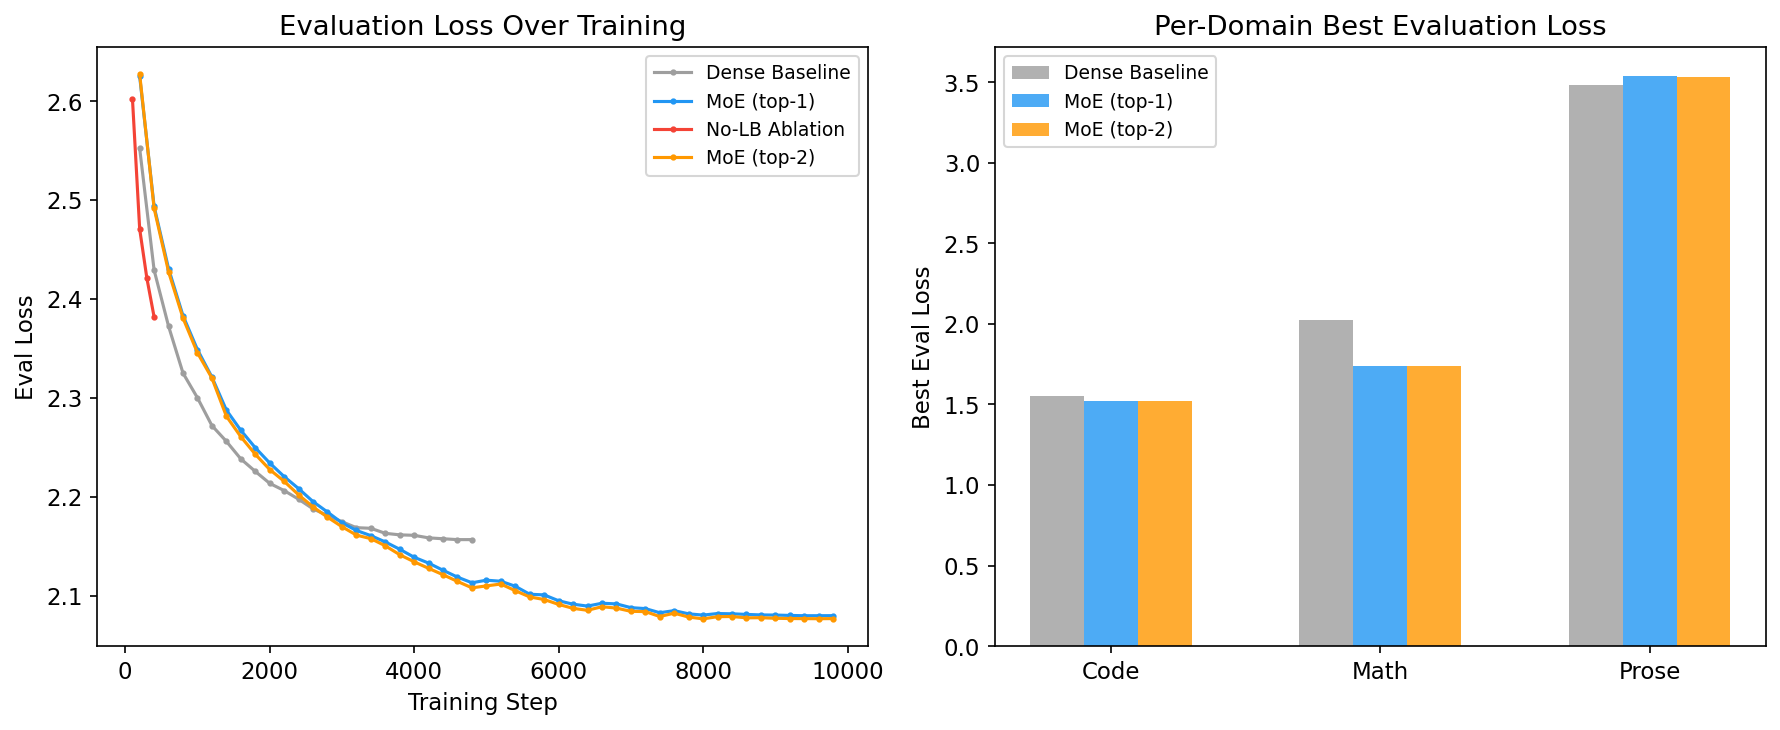

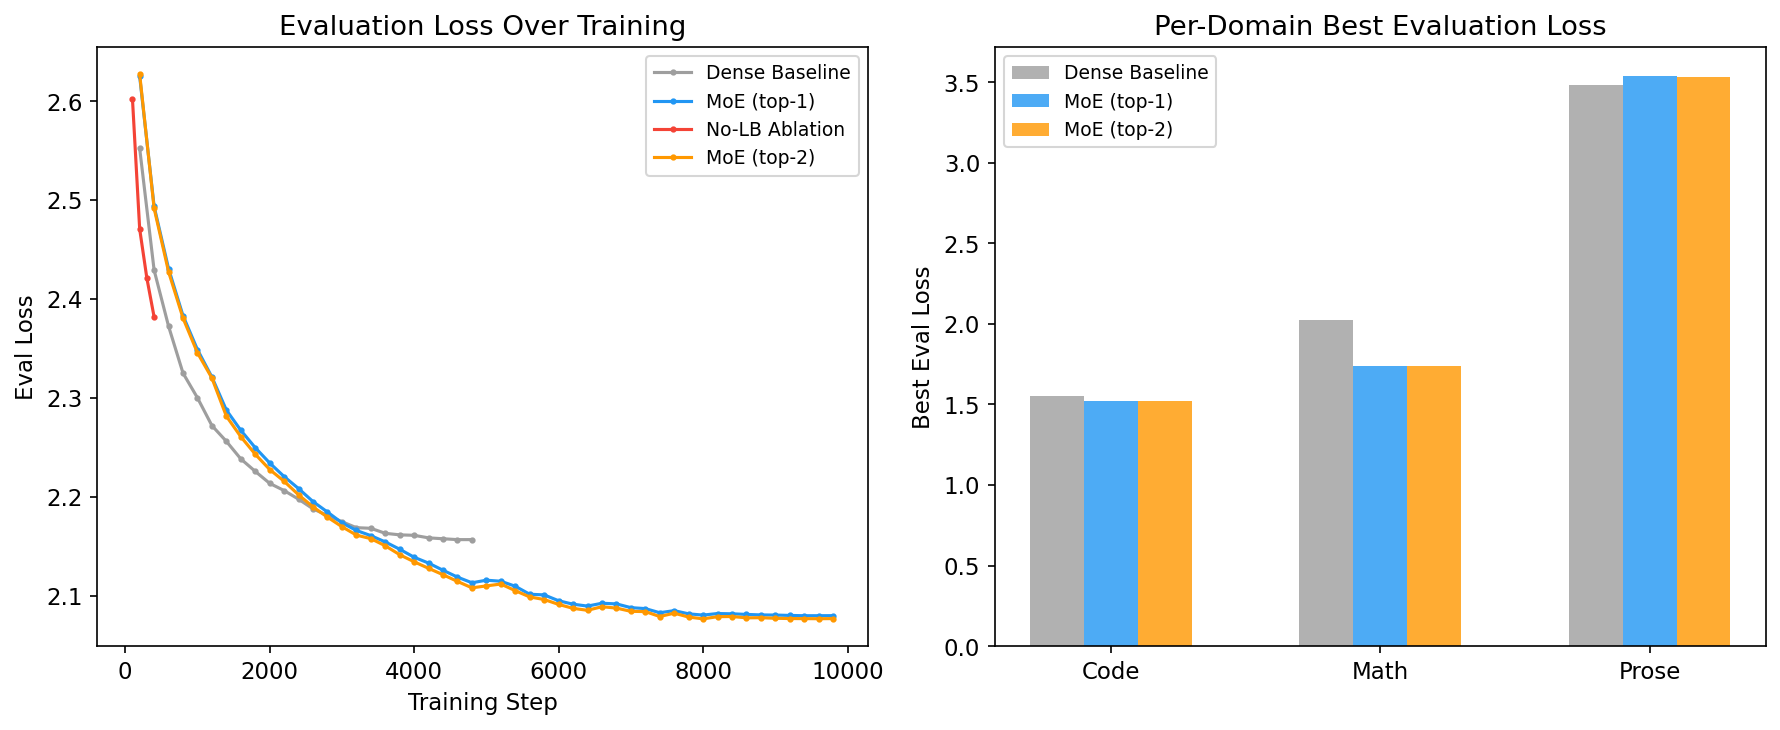

In [17]:
# Cell 7: Training curves (all 4 runs)
runs = {
    "dense": CKPT / "dense-baseline/metrics.jsonl",
    "moe-main": CKPT / "moe-main/metrics.jsonl",
    "no-lb": CKPT / "no-lb-ablation/metrics.jsonl",
    "top-2": CKPT / "top2-main-10k/metrics.jsonl",
}

metrics_dict = {name: load_metrics_jsonl(path) for name, path in runs.items()}
best_evals = {name: get_best_eval_metrics(path) for name, path in runs.items()}

print("Best eval losses:")
for name, best in best_evals.items():
    if best:
        print(f"  {name}: {best.get('eval/loss', 'N/A'):.4f} at step {int(best.get('step', 0))}")

fig_curves = plot_training_curves(metrics_dict, best_evals)
fig_curves

In [18]:
# Cell 8: Save all figures
print("Saving figures...")

fig_heatmap.savefig(FIGURES / "expert_domain_heatmaps.png", dpi=300, bbox_inches="tight")
print("  expert_domain_heatmaps.png")

fig_collapse.savefig(FIGURES / "collapse_comparison_layer9.png", dpi=300, bbox_inches="tight")
print("  collapse_comparison_layer9.png")

fig_trajectory.savefig(FIGURES / "collapse_trajectory_layer9.png", dpi=300, bbox_inches="tight")
print("  collapse_trajectory_layer9.png")

fig_entropy.savefig(FIGURES / "router_entropy_over_training.png", dpi=300, bbox_inches="tight")
print("  router_entropy_over_training.png")

fig_token.savefig(FIGURES / "token_type_routing_layer9.png", dpi=300, bbox_inches="tight")
print("  token_type_routing_layer9.png")

fig_curves.savefig(FIGURES / "training_curves.png", dpi=300, bbox_inches="tight")
print("  training_curves.png")

# also save heatmaps for other layers
for layer in [8, 10, 11]:
    fig_tt = plot_token_type_routing(token_type_fracs, layer)
    fig_tt.savefig(FIGURES / f"token_type_routing_layer{layer}.png", dpi=300, bbox_inches="tight")
    import matplotlib.pyplot as plt
    plt.close(fig_tt)
    print(f"  token_type_routing_layer{layer}.png")

for layer in [8, 10, 11]:
    fig_col = plot_collapse_comparison(moe_util, nolb_fracs, layer)
    fig_col.savefig(FIGURES / f"collapse_comparison_layer{layer}.png", dpi=300, bbox_inches="tight")
    plt.close(fig_col)
    print(f"  collapse_comparison_layer{layer}.png")

print(f"\nAll figures saved to {FIGURES.resolve()}")

Saving figures...
  expert_domain_heatmaps.png
  collapse_comparison_layer9.png
  collapse_trajectory_layer9.png
  router_entropy_over_training.png
  token_type_routing_layer9.png
  training_curves.png
  token_type_routing_layer8.png
  token_type_routing_layer10.png
  token_type_routing_layer11.png
  collapse_comparison_layer8.png
  collapse_comparison_layer10.png
  collapse_comparison_layer11.png

All figures saved to /Users/sumit/playground/moe-emergence/figures
